In [33]:
import os
os.environ['USE_PYGEOS'] = '0'
path = os.getcwd()
import sys
from os.path import join as pjoin
from pathlib import Path
import numpy as np
import rioxarray
import numpy as np
import joblib
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
import warnings
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
from collections import defaultdict

warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.cluster._kmeans')

gmm = joblib.load("..\\models\\gmm_B(2022,2023)_k10_init3_MS_median_bathy_11F.pkl")

# Get project root to allow for relative imports
notebook_dir = Path(os.getcwd())
project_root = notebook_dir.parent

print(f"Project root: {project_root}")

# Add PROJECT ROOT to sys.path
sys.path.insert(0, str(project_root))

from scripts.features import prepare_data
# from scripts import model as M
from scripts.data_loading import compute_bands_all
from scripts import cache
from scripts import config 

Project root: c:\Users\denni\OneDrive\Documenten\ADS\Spatial Simulation Modelling\Project\RemoteSensing_CoralReefs


c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator GaussianMixture from version 1.5.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


# Computing Silhouette score

In [34]:
tiff_path = "..//data//raw//PSScene//20240607_000749_84_24e5_3B_AnalyticMS_SR_8b_clip_philip.tif"
band = rioxarray.open_rasterio(tiff_path)
data_monthly = np.load("..//data//interim//monthly_data_B(2022,2023)_k10_init3_MS_median_bathy_11F.npy")
labels_monthly = np.load("..//data//interim//predictions_monthly_B(2022,2023)_k10_init3_MS_median_bathy_11F_labels.npy")
mask_monthly = np.load("..//data//interim//monthly_data_B(2022,2023)_k10_init3_MS_median_bathy_11F_mask.npy")

In [35]:
# Checking the amount of pixels per picture
size_x, size_y = band[1].shape[0], band[1].shape[1]
pixel_per_timestamp = size_x * size_y 

# Sanity check to ensure that the amount of data can be divided over 48 months
len(mask_monthly)/pixel_per_timestamp == 48.0

True

In [4]:
"""
Silhouette score measures how well each point fits its cluster vs neighbouring clusters.
Score ranges from -1 to 1:
    1.0  = perfect separation
    0.0  = overlapping clusters  
    -1.0  = points assigned to wrong cluster
"""

def bootstrap(sample_size, data,  gmm):
    """Idea is that a mean proportion per cluster per month
    is computed. Then the Bootstrap CI95 will be computed
    as well as the stdev. 

    Returns:
        _type_: _description_
    """
    random_index = np.random.randint(len(data), size=sample_size)
    bootstrap_data = data[random_index]
    pred_boot = gmm.predict(bootstrap_data)
    pred_counts = np.bincount(pred_boot)
    props = pred_counts / pred_counts.sum()
    return props


start_index = 0
dict_info = defaultdict(list)
for t in range(48):

    mask_true = mask_monthly[t*pixel_per_timestamp:(t+1)*pixel_per_timestamp]
    valid_pixels = len(mask_true[mask_true])
    data = data_monthly[start_index:start_index + valid_pixels]
    labels = labels_monthly[start_index:start_index + valid_pixels]

    # Using all data for calculations was too slow, therefore a subsample is used
    sil_score = silhouette_score(data, labels, sample_size=config.SAMPLE_SIZE_BOOT, random_state=35)

    with ThreadPoolExecutor() as executor:
        proportions = list(
            executor.map(
                bootstrap,
                [config.SAMPLE_SIZE_BOOT] * config.N_BOOT,
                [data] * config.N_BOOT,
                [gmm] * config.N_BOOT
            )
        )

    proportions = np.array(proportions)
    mean  = proportions.mean(axis=0)
    stdev = proportions.std(axis=0)

    # Computes the bootstrap confidence interval
    lower = np.percentile(proportions, 2.5, axis=0)
    upper = np.percentile(proportions, 97.5, axis=0)

    dict_info["time"].append(t)
    dict_info["mean"].append(mean)
    dict_info["stdev"].append(stdev)
    dict_info["lower"].append(lower)
    dict_info["upper"].append(upper)
    dict_info["silhouette_score"].append(sil_score)

    start_index += valid_pixels
    # silhouette_scores.append(sil_score)

# Save to parquet as this helps maintain column information (which is a list)
pd.DataFrame(dict_info).to_parquet("..//data//processed//validation_results//bootstrap_mean_results.parquet")


: 

In [ ]:
import pandas as pd
df = pd.read_parquet("..//data//processed//validation_results//bootstrap_mean_results.parquet")
df_ari = pd.read_parquet("..//data//processed//validation_results//ari_results.parquet")

In [4]:
df.head()

,time,mean,stdev,lower,upper,silhouette_score
0,0,"[0.2617629, 0.021125600000000026, 0.1473761999...","[0.0043222255366882475, 0.0014710964074458215,...","[0.2533, 0.0182, 0.1404, 0.2869, 0.0025, 0.036...","[0.27040499999999995, 0.0241, 0.1544, 0.3041, ...",-0.068736
1,1,"[0.1475697000000002, 0.018926400000000003, 0.0...","[0.0035609313262122896, 0.0013915541814819873,...","[0.1403, 0.0162975, 0.011, 0.1018975, 0.0264, ...","[0.1544, 0.0218025, 0.0154, 0.1137, 0.03290249...",0.049075
2,2,"[0.11296970000000005, 0.021206799999999977, 0....","[0.0031052587508933905, 0.001444352366979747, ...","[0.1068, 0.0185, 0.0768, 0.3232, 0.0737, 0.048...","[0.118905, 0.0242, 0.0865, 0.34160250000000003...",0.013330
3,3,"[0.0713607, 0.050437500000000024, 0.0192207000...","[0.0025707597145591026, 0.0021448924798227052,...","[0.0663, 0.0463, 0.0165, 0.14759750000000002, ...","[0.0763, 0.0547, 0.0219, 0.1607025, 0.0257, 0....",0.016010
4,4,"[0.2202604000000001, 0.02790209999999997, 0.03...","[0.0041658362713865756, 0.001659344927976099, ...","[0.2122, 0.0248, 0.0281, 0.16879750000000002, ...","[0.228305, 0.031102499999999998, 0.0352, 0.183...",0.032269


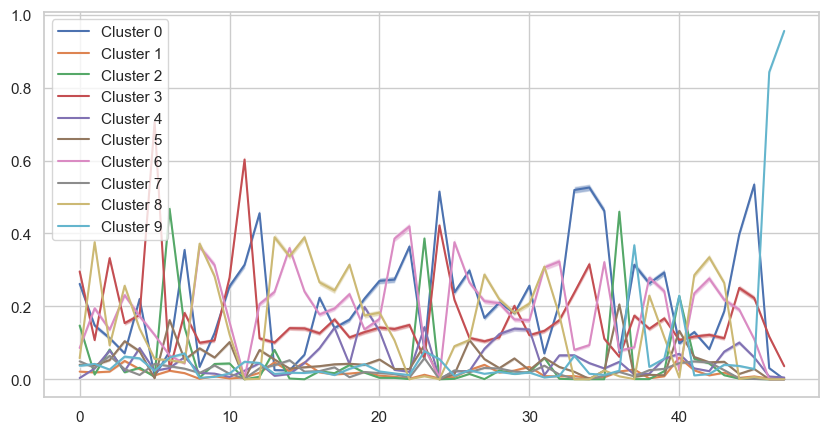

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
means = np.vstack(df["mean"])
lowers = np.vstack(df["lower"])
uppers = np.vstack(df["upper"])
time = np.vstack(df["time"])

for k in range(means.shape[1]):
    plt.plot(time, means[:, k], label=f"Cluster {k}")
    plt.fill_between(time[:,0], lowers[:, k], uppers[:, k], alpha=0.5)

plt.legend()
plt.show()

Below is the proportion plotted from one cluster together with the bootstrap 95%-CI over time. 

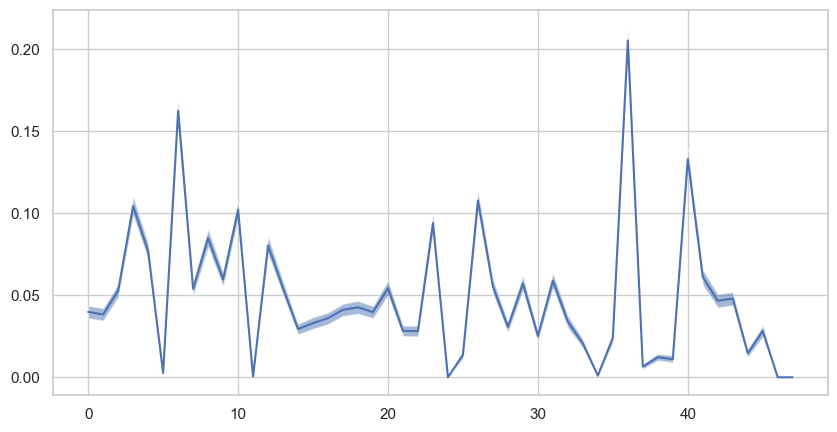

In [ ]:

cluster_no = 5
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
plt.plot(time, means[:, cluster_no], label=f"Cluster {cluster_no}")
plt.fill_between(time[:,0], lowers[:, cluster_no], uppers[:, cluster_no], alpha=0.5)

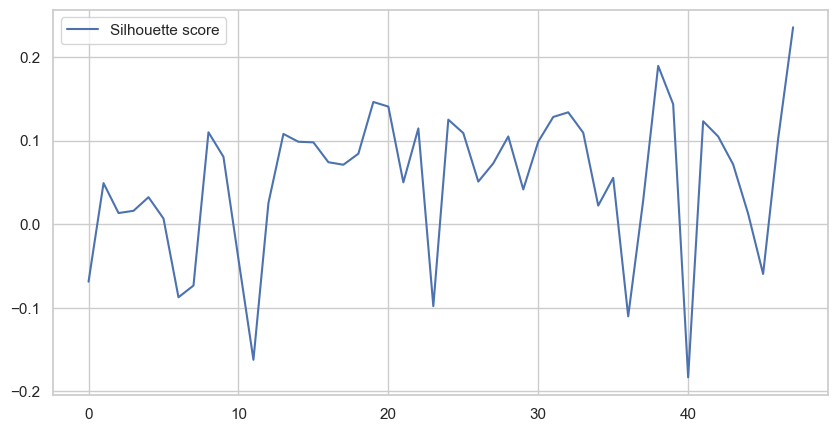

In [25]:
plt.figure(figsize=(10, 5))

time = np.vstack(df["time"])

plt.plot(time, df["silhouette_score"].tolist(), label=f"Silhouette score")

plt.legend()
plt.show()

In [28]:
data_monthly

array([[-1.5577756 , -1.6199884 , -1.6757064 , ..., -0.01482974,
         0.58488315, -1.6214737 ],
       [-1.5577756 , -1.6199884 , -1.6757064 , ...,  0.4551671 ,
         0.7052228 , -3.079415  ],
       [-1.5577756 , -1.6199884 , -1.6757064 , ...,  0.15970623,
         1.5540211 , -3.079415  ],
       ...,
       [ 0.27333978, -0.01378421, -0.47769544, ...,  0.97854084,
         1.7944212 ,  0.6961579 ],
       [ 0.37678593,  0.02585186, -0.2789581 , ...,  0.39175647,
         1.7815053 ,  0.5437068 ],
       [ 0.43385968,  0.00792126, -0.34919462, ...,  0.57136405,
         1.7431654 ,  0.7859555 ]], dtype=float32)

In [15]:
means.shape[1]

10

In [ ]:
dict_ari = defaultdict(list)

def bootstrap_ari(data, labels):
    random_index = np.random.randint(len(data), size=10000)

    bootstrap_data = data[random_index]
    gmm_boot = GaussianMixture(n_components=config.GMM_COMPONENTS, random_state=35, n_init=config.GMM_N_INIT)
    gmm_boot.fit(bootstrap_data)

    y_boot = gmm_boot.predict(data)

    return adjusted_rand_score(labels, y_boot)

os.environ["LOKY_MAX_CPU_COUNT"] = "4"
start_index = 0

for t in range(48):
    mask_true = mask_monthly[t*pixel_per_timestamp:(t+1)*pixel_per_timestamp]
    valid_pixels = len(mask_true[mask_true])
    data = data_monthly[start_index:start_index + valid_pixels]
    labels = labels_monthly[start_index:start_index + valid_pixels]

    with ThreadPoolExecutor() as executor:
        ari_scores = list(
            executor.map(
                bootstrap_ari,
                [data] * 5,
                [labels] * 5,
            )
        )
    print(ari_scores)
    ari_scores = np.array(ari_scores)
    mean  = ari_scores.mean(axis=0)
    stdev = ari_scores.std(axis=0)
    dict_ari["time"].append(t)
    dict_ari["mean"].append(mean)
    dict_ari["stdev"].append(stdev)
    start_index += valid_pixels

pd.DataFrame(dict_ari).to_csv("..//data//processed//validation_results//ari_results.parquet")

c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\scipy\special\_logsumexp.py:125: RuntimeWarning: divide by zero encountered in log
  out_inf = xp.log(sum_)
c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\scipy\special\_logsumexp.py:125: RuntimeWarning: divide by zero encountered in log
  out_inf = xp.log(sum_)
c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\

[0.388084290788886, 0.3948130210851513, 0.33219110429564536, 0.3480476568349628, 0.4404177757767854]


c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\scipy\special\_logsumexp.py:125: RuntimeWarning: divide by zero encountered in log
  out_inf = xp.log(sum_)
c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\scipy\special\_logsumexp.py:125: RuntimeWarning: divide by zero encountered in log
  out_inf = xp.log(sum_)
c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\scipy\special\_logsumexp.py:125: RuntimeWarning: divide by zero encountered in log
  out_inf = xp.log(sum_)
c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\scipy\special\_logsumexp.py:125: RuntimeWarning: divide by zero encountered in log
  out_inf = xp.log(sum_)
c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\scipy\special\_logsumexp.py:125: RuntimeWarning: divide by zero encountered in log
  out_inf = xp.log(sum_)
c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-p

[0.3192665759125639, 0.3063824108517523, 0.4000410833675646, 0.32000581783180193, 0.36658736066893177]


c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\scipy\special\_logsumexp.py:125: RuntimeWarning: divide by zero encountered in log
  out_inf = xp.log(sum_)
c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\scipy\special\_logsumexp.py:125: RuntimeWarning: divide by zero encountered in log
  out_inf = xp.log(sum_)
c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\scipy\special\_logsumexp.py:125: RuntimeWarning: divide by zero encountered in log
  out_inf = xp.log(sum_)
c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\scipy\special\_logsumexp.py:125: RuntimeWarning: divide by zero encountered in log
  out_inf = xp.log(sum_)
c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\scipy\special\_logsumexp.py:125: RuntimeWarning: divide by zero encountered in log
  out_inf = xp.log(sum_)
c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-p

...

c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\scipy\special\_logsumexp.py:125: RuntimeWarning: divide by zero encountered in log
  out_inf = xp.log(sum_)
c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\scipy\special\_logsumexp.py:125: RuntimeWarning: divide by zero encountered in log
  out_inf = xp.log(sum_)
c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\scipy\special\_logsumexp.py:125: RuntimeWarning: divide by zero encountered in log
  out_inf = xp.log(sum_)
c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\scipy\special\_logsumexp.py:125: RuntimeWarning: divide by zero encountered in log
  out_inf = xp.log(sum_)
c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\scipy\special\_logsumexp.py:125: RuntimeWarning: divide by zero encountered in log
  out_inf = xp.log(sum_)
c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-p

[0.0832679337312998, 0.05281048715991395, 0.05029512600113596, 0.05451456447320477, 0.050145982561615884]


c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\scipy\special\_logsumexp.py:125: RuntimeWarning: divide by zero encountered in log
  out_inf = xp.log(sum_)
c:\Users\denni\OneDrive\Documenten\Anaconda\envs\geospatial\Lib\site-packages\scipy\special\_logsumexp.py:125: RuntimeWarning: divide by zero encountered in log
  out_inf = xp.log(sum_)


[0.011963494862476633, 0.014473498826722048, 0.011632692890742357, 0.005130830948238368, 0.009132491670585968]


: 

In [1]:
import pandas as pd

df = pd.read_csv("..//data//processed//validation_results//ari_results.csv")
df.to_parquet("..//data//processed//validation_results//ari_results.parquet")

In [2]:
df = pd.read_parquet("..//data//processed//validation_results//ari_results.parquet")
df.head()

,Unnamed: 0,time,mean,stdev
0,0,0,0.380711,0.038051
1,1,1,0.342457,0.035331
2,2,2,0.318225,0.007326
3,3,3,0.404071,0.020173
4,4,4,0.396270,0.035755


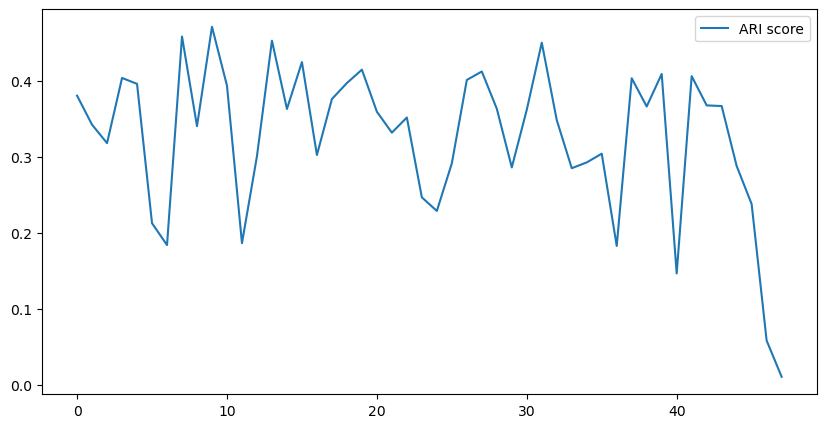

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10, 5))

plt.plot(df["time"].tolist(), df["mean"].tolist(), label=f"ARI score")

plt.legend()
plt.show()